### **Vision Transformer Architecture**

In [1]:
#import libraries
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import os #check for filepath
import torch
import torch.nn as nn
from torchvision import transforms
from PIL import Image
from sklearn.model_selection import train_test_split

In [2]:
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {DEVICE}')

Device: cuda


In [3]:
class PatchEmbedding(nn.Module):
  def __init__(self, patch_size=16, img_size=224, in_channels=3, embedding=768): #set as default
    super().__init__()
    self.n_patches = (img_size // patch_size) ** 2 # 224/16=14

    self.proj = nn.Conv2d(in_channels, out_channels = embedding, kernel_size = patch_size, stride=patch_size)
    #slides over patches and dot product with weights (randomly initialized at first)

  def forward(self, x):
    x = self.proj(x) # (B, 3, 224, 224) -> (B, 768, 14, 14)
    x = x.flatten(2)
    x = x.transpose(1,2) # (B, 196, 768) 196 tokens with 768 features (vector)
    return x

In [4]:
class PositionalEncoding(nn.Module):
    def __init__(self, n_patches=196, embedding=768):
        super().__init__()

        self.cls_token = nn.Parameter(torch.zeros(1, 1, embedding)) # classification token starts at zero, all tokens are of same dimension
        self.pos_embed = nn.Parameter(torch.zeros(1, n_patches + 1, embedding)) # position of token in learned during training

    def forward(self, x):
        B = x.shape[0]

        cls = self.cls_token.expand(B, -1, -1)  #each image gets a cls token
        x = torch.cat([cls, x], dim=1) # concatenate the cls token with 196 patches (B, 197, 768)
        x = x + self.pos_embed 

        return x  # (B, 197, 768)

In [5]:
class MultiHeadAttention(nn.Module):
    def __init__(self, embedding=768, n_heads=12):
        super().__init__()

        self.n_heads = n_heads # 12 independent attention computations

        # 768 / 12 = 64 features
        self.head_dim = embedding // n_heads

        self.queries = nn.Linear(embedding, embedding) #n_inputs = n_outputs
        self.keys = nn.Linear(embedding, embedding)
        self.values = nn.Linear(embedding, embedding)

        self.out_proj = nn.Linear(embedding, embedding)

    def forward(self, x):
        batch, n_tokens, embed_dim = x.shape 

        # project every token into queries, keys, values
        Q = self.queries(x)  # (B, 197, 768)
        K = self.keys(x)
        V = self.values(x)

        # split 768 features across 12 heads
        Q = Q.view(batch, n_tokens, self.n_heads, self.head_dim).transpose(1, 2)  # (B, 12, 197, 64)
        K = K.view(batch, n_tokens, self.n_heads, self.head_dim).transpose(1, 2)
        V = V.view(batch, n_tokens, self.n_heads, self.head_dim).transpose(1, 2)

        # Attention(Q, K, V) = softmax( QK^T / sqrt(d_k) ) * V
        scale = self.head_dim ** 0.5
        scores = (Q @ K.transpose(-2, -1)) / scale  # (B, 12, 197, 197)

        # softmax 
        weights = torch.softmax(scores, dim=-1)  # (B, 12, 197, 197)

        #   weighted sum of values
        attention_output = weights @ V  # (B, 12, 197, 64)

        # merge all 12 heads 
        attention_output = attention_output.transpose(1, 2).reshape(batch, n_tokens, embed_dim)  # (B, 197, 768)

        # final linear projection
        x = self.out_proj(attention_output)  # (B, 197, 768)

        return x

In [6]:
class MLP(nn.Module):
    def __init__(self, embedding=768, mlp_ratio=4):
        super().__init__()

        # hidden layer is 4 times bigger than the embedding dim
        hidden = embedding * mlp_ratio

        self.layer1 = nn.Linear(embedding, hidden)   # expand
        self.act_func  = nn.GELU()
        self.layer2  = nn.Linear(hidden, embedding)    # compress

    def forward(self, x):
        x = self.layer1(x)  
        x = self.act_func(x)   
        x = self.layer2(x)   
        return x

In [7]:
class TransformerBlock(nn.Module):
    def __init__(self, embedding=768, n_heads=12, mlp_ratio=4, dropout=0.1): # Added dropout parameter
        super().__init__()

        # normalisation
        self.norm1 = nn.LayerNorm(embedding)
        self.norm2 = nn.LayerNorm(embedding)

        self.attention = MultiHeadAttention(embedding, n_heads)
        self.mlp       = MLP(embedding, mlp_ratio)
        self.dropout   = nn.Dropout(dropout)

    def forward(self, x):
        # normalise first, run attention, then add the input back (residual)
        x = x + self.dropout(self.attention(self.norm1(x)))

        # MLP sub-layer
        x = x + self.dropout(self.mlp(self.norm2(x)))

        return x  #(B, 197, 768)

In [8]:
class VisionTransformer(nn.Module):
    def __init__(self, img_size=224, patch_size=16, in_channels=3, embedding=256, n_heads=8,
                 n_layers=6, mlp_ratio=4, n_classes=10, dropout=0.1): # Added dropout parameter
        super().__init__()

        n_patches = (img_size // patch_size) ** 2  # 196

        # block 1 — image into patch tokens
        self.patch_embedding = PatchEmbedding(patch_size, img_size, in_channels, embedding)

        # block 2 — add CLS token and position information
        self.positional_encoding = PositionalEncoding(n_patches, embedding)

        # block 3+4+5 — stack of transformer blocks
        # each block runs attention then MLP
        self.transformer_blocks = nn.Sequential(*[
            TransformerBlock(embedding, n_heads, mlp_ratio, dropout) # Passed dropout to TransformerBlock
            for _ in range(n_layers)
        ])

        # final layer norm before classification
        self.norm = nn.LayerNorm(embedding)

        # classification head — takes CLS token and produces class scores
        self.classifier = nn.Linear(embedding, n_classes)

    def forward(self, x):

        # step 1 — cut image into patches and project each to embedding dim
        x = self.patch_embedding(x)        # (B, 3, 224, 224) -> (B, 196, embedding)

        # step 2 — prepend CLS token and add position information
        x = self.positional_encoding(x)    # (B, 196, embedding) -> (B, 197, embedding)

        # step 3 — pass through transformer blocks
        x = self.transformer_blocks(x)     # (B, 197, embedding)

        # step 4 — normalise
        x = self.norm(x)

        # step 5 — pull out just the CLS token (position 0)
        cls_output = x[:, 0]

        # step 6 — classify using the CLS summary
        out = self.classifier(cls_output)

        return out

### **Training block**


In [9]:
import os
import pandas as pd
from pathlib import Path

data_path = Path(r"C:\Users\User\OneDrive\Desktop\data")

# Load CSVs
train_df = pd.read_csv(data_path / "train.csv")
test_df  = pd.read_csv(data_path / "test.csv")

# Build local image paths
def fix_path(raw_path):
    clean = str(raw_path).replace('\\', '/')
    parts = clean.split('/')
    class_folder = parts[-2]
    filename = parts[-1]
    return str(data_path / "food-101" / "images" / class_folder / filename)

train_df['image_path'] = train_df['image_path'].apply(fix_path)
test_df['image_path']  = test_df['image_path'].apply(fix_path)

# Build class mappings
classes  = sorted(train_df['label_name'].unique())
cls2idx  = {c: i for i, c in enumerate(classes)}
idx2cls  = {i: c for c, i in cls2idx.items()}
train_df['label'] = train_df['label_name'].map(cls2idx)

N_CLASSES = len(classes)
print(f'{N_CLASSES} classes: {classes}')
print(f'Training images: {len(train_df)} | Test images: {len(test_df)}')

# Verify path looks correct
print(train_df['image_path'].iloc[0])

10 classes: ['baby_back_ribs', 'beef_tartare', 'cheesecake', 'crab_cakes', 'dumplings', 'french_onion_soup', 'guacamole', 'hot_and_sour_soup', 'pork_chop', 'sushi']
Training images: 7500 | Test images: 2500
C:\Users\User\OneDrive\Desktop\data\food-101\images\hot_and_sour_soup\1002782.jpg


In [10]:
# Transforms: resize and normalise every image before feeding it to the model
from torch.utils.data import Dataset  # Import Dataset

train_transform = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.6, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.4, contrast=0.4, saturation=0.3),
    transforms.RandomGrayscale(p=0.1),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

val_transform = transforms.Compose([
    transforms.Resize(256),              # no random augmentation for val/test
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

# load images and labels from dataframe, apply transforms
class FoodDataset(Dataset):
    def __init__(self, df, transform, has_labels=True):
        self.paths      = df['image_path'].tolist()
        self.labels     = df['label'].tolist() if has_labels else None
        self.transform  = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        image = Image.open(self.paths[idx]).convert('RGB')
        image = self.transform(image)
        if self.labels is not None:
            return image, self.labels[idx]
        return image

In [11]:
print(os.listdir(data_path / "food-101"/ "images"))

['.DS_Store', 'baby_back_ribs', 'beef_tartare', 'cheesecake', 'crab_cakes', 'dumplings', 'french_onion_soup', 'guacamole', 'hot_and_sour_soup', 'pork_chop', 'sushi']


In [12]:
import os
from pathlib import Path

# Check if the first image actually exists
first_path = train_df['image_path'].iloc[0]
print(f'Path: {first_path}')
print(f'File exists: {os.path.exists(first_path)}')

# Show what files are actually in that folder
path_obj = Path(first_path)
class_folder = path_obj.parent.name
folder_path = path_obj.parent
print(f'\nFirst 5 files in {class_folder}:')
print(os.listdir(folder_path)[:5])

Path: C:\Users\User\OneDrive\Desktop\data\food-101\images\hot_and_sour_soup\1002782.jpg
File exists: True

First 5 files in hot_and_sour_soup:
['1000486.jpg', '1002782.jpg', '1003688.jpg', '1004564.jpg', '1008185.jpg']


In [ ]:
from itertools import product
from sklearn.model_selection import StratifiedKFold
from torch.utils.data import DataLoader
import numpy as np

param_grid = {
    'lr'          : [3e-4, 1e-4],         
    'weight_decay': [1e-3, 1e-2],   
    'dropout'     : [0.1,  0.3],    
    'batch_size'  : [16, 32],            
}

CV_FOLDS  = 3   
CV_EPOCHS = 5   

results      = []
combos       = list(product(*param_grid.values()))
keys         = list(param_grid.keys())
labels_array = train_df['label'].values

for combo in combos:

    params    = dict(zip(keys, combo))
    fold_accs = []

    skf = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=42)

    for fold, (train_idx, val_idx) in enumerate(skf.split(np.zeros(len(labels_array)), labels_array)):

        train_fold = train_df.iloc[train_idx].reset_index(drop=True)
        val_fold   = train_df.iloc[val_idx].reset_index(drop=True)

        train_loader = DataLoader(
            FoodDataset(train_fold, train_transform),
            batch_size=params['batch_size'],  
            shuffle=True,
            num_workers=0
        )
        val_loader = DataLoader(
            FoodDataset(val_fold, val_transform),
            batch_size=params['batch_size'],  
            shuffle=False,
            num_workers=0
        )

        model     = VisionTransformer(n_classes=N_CLASSES, embedding=256, n_heads=8, n_layers=6, dropout=params['dropout']).to(DEVICE)
        optimizer = torch.optim.AdamW(model.parameters(), lr=params['lr'], weight_decay=params['weight_decay'])
        criterion = nn.CrossEntropyLoss()

        # cosine annealing over CV_EPOCHS — gives a fairer comparison across configs
        # than a flat lr, since some configs may need more warmup than others
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
            optimizer, T_max=CV_EPOCHS, eta_min=1e-6
        )

        for epoch in range(CV_EPOCHS):
            model.train()
            for batch_idx, (images, labels) in enumerate(train_loader):
                images, labels = images.to(DEVICE), labels.to(DEVICE)
                optimizer.zero_grad()
                loss = criterion(model(images), labels)
                loss.backward()
                optimizer.step()
                if batch_idx % 50 == 0:
                    print(f"    Epoch {epoch+1}/{CV_EPOCHS} | Batch {batch_idx}/{len(train_loader)} | Loss: {loss.item():.4f}")
            scheduler.step()

        model.eval()
        correct, total = 0, 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(DEVICE), labels.to(DEVICE)
                correct += (model(images).argmax(1) == labels).sum().item()
                total   += labels.size(0)

        fold_acc = correct / total * 100
        fold_accs.append(fold_acc)
        config_view = {'lr': params['lr'], 'weight_decay': params['weight_decay'], 'dropout': params['dropout']}
        print(f"Config {config_view} | Fold {fold+1}/{CV_FOLDS} | Acc: {fold_acc:.2f}%")

        del model
        torch.cuda.empty_cache()

    mean_acc = np.mean(fold_accs)
    std_acc  = np.std(fold_accs)   # added — high std means the config is unstable across folds
    results.append({**params, 'val_acc': round(mean_acc, 2), 'val_std': round(std_acc, 2)})
    print(f" -> lr={params['lr']}  wd={params['weight_decay']}  dropout={params['dropout']}  bs={params['batch_size']}")
    print(f"  Accuracy: {mean_acc:.2f}% ± {std_acc:.2f}%\n")

results_df = pd.DataFrame(results).sort_values('val_acc', ascending=False).reset_index(drop=True)

print(results_df.to_string(index=False))

best = results_df.iloc[0]
print(f'\nBest config: lr={best.lr}  weight_decay={best.weight_decay}  dropout={best.dropout}  batch_size={best.batch_size}')
print(f'Best CV accuracy: {best.val_acc}% ± {best.val_std}%')

    Epoch 1/5 | Batch 0/313 | Loss: 2.2723
    Epoch 1/5 | Batch 50/313 | Loss: 2.3048
    Epoch 1/5 | Batch 100/313 | Loss: 2.2755
    Epoch 1/5 | Batch 150/313 | Loss: 2.2522
    Epoch 1/5 | Batch 200/313 | Loss: 2.1214
    Epoch 1/5 | Batch 250/313 | Loss: 2.1341
    Epoch 1/5 | Batch 300/313 | Loss: 2.2533
    Epoch 2/5 | Batch 0/313 | Loss: 1.8104
    Epoch 2/5 | Batch 50/313 | Loss: 2.1867
    Epoch 2/5 | Batch 100/313 | Loss: 2.1891
    Epoch 2/5 | Batch 150/313 | Loss: 2.1306
    Epoch 2/5 | Batch 200/313 | Loss: 1.9310
    Epoch 2/5 | Batch 250/313 | Loss: 2.0084
    Epoch 2/5 | Batch 300/313 | Loss: 2.2580
    Epoch 3/5 | Batch 0/313 | Loss: 2.1881
    Epoch 3/5 | Batch 50/313 | Loss: 2.0726
    Epoch 3/5 | Batch 100/313 | Loss: 1.8160
    Epoch 3/5 | Batch 150/313 | Loss: 1.9725
    Epoch 3/5 | Batch 200/313 | Loss: 1.8986
    Epoch 3/5 | Batch 250/313 | Loss: 2.1952
    Epoch 3/5 | Batch 300/313 | Loss: 1.8316
    Epoch 4/5 | Batch 0/313 | Loss: 1.9361
    Epoch 4/5 | Batch

In [29]:
best = results_df.iloc[0]
print(f'Using best config -> lr={best.lr}  wd={best.weight_decay}  dropout={best.dropout}')
print(f'Grid search CV accuracy: {best.val_acc}%\n')

EPOCHS = 100
WARMUP = 10

# 80/20 split - validation
train_split, val_split = train_test_split(
    train_df, test_size=0.2, stratify=train_df['label'], random_state=42
)
print(f'Train: {len(train_split)} | Test: {len(val_split)}')

train_loader = DataLoader(FoodDataset(train_split, train_transform), batch_size=16, shuffle=True,  num_workers=0)
val_loader   = DataLoader(FoodDataset(val_split,   val_transform),   batch_size=16, shuffle=False, num_workers=0)
test_loader  = DataLoader(FoodDataset(test_df,     val_transform,    has_labels=False), batch_size=16, shuffle=False, num_workers=0)

model     = VisionTransformer(n_classes=N_CLASSES, embedding=256, n_heads=8, n_layers=6, dropout=float(best.dropout)).to(DEVICE)
optimizer = torch.optim.AdamW(model.parameters(), lr=float(best.lr), weight_decay=float(best.weight_decay))
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

def get_lr(epoch):
    if epoch < WARMUP:
        return epoch / WARMUP
    progress = (epoch - WARMUP) / (EPOCHS - WARMUP)
    return 0.5 * (1 + np.cos(np.pi * progress))

scheduler    = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda=get_lr)
best_acc     = 0.0
train_losses = []
val_losses   = []
train_accs   = []
val_accs     = []

for epoch in range(1, EPOCHS + 1):

    # training
    model.train()
    train_loss, correct, total = 0.0, 0, 0
    for images, labels in train_loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        outputs = model(images)
        loss    = criterion(outputs, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        train_loss += loss.item()
        correct    += (outputs.argmax(1) == labels).sum().item()
        total      += labels.size(0)

    scheduler.step()
    avg_train_loss = train_loss / len(train_loader)
    avg_train_acc  = correct / total * 100
    train_losses.append(avg_train_loss)
    train_accs.append(avg_train_acc)

    # validation
    model.eval()
    val_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            outputs = model(images)
            loss    = criterion(outputs, labels)
            val_loss += loss.item()
            correct  += (outputs.argmax(1) == labels).sum().item()
            total    += labels.size(0)

    avg_val_loss = val_loss / len(val_loader)
    avg_val_acc  = correct / total * 100
    val_losses.append(avg_val_loss)
    val_accs.append(avg_val_acc)

    current_lr = optimizer.param_groups[0]['lr']

    if avg_val_acc > best_acc:
        best_acc = avg_val_acc
        torch.save(model.state_dict(), 'best_vit.pth')
        flag = '<- saved'
    else:
        flag = ''

    print(f'Epoch {epoch:02d}/{EPOCHS}  |  LR: {current_lr:.6f}  |  '
          f'Train Loss: {avg_train_loss:.4f}  Train Acc: {avg_train_acc:.2f}%  |  '
          f'Val Loss: {avg_val_loss:.4f}  Val Acc: {avg_val_acc:.2f}%{flag}')

print(f'\nBest validation accuracy: {best_acc:.2f}%')

Using best config -> lr=0.0001  wd=0.001  dropout=0.1
Grid search CV accuracy: 41.65%

Train: 6000 | Test: 1500
Epoch 01/100  |  LR: 0.000010  |  Train Loss: 2.4211  Train Acc: 10.15%  |  Val Loss: 2.4229  Val Acc: 8.47%<- saved
Epoch 02/100  |  LR: 0.000020  |  Train Loss: 2.2708  Train Acc: 16.57%  |  Val Loss: 2.1594  Val Acc: 22.93%<- saved
Epoch 03/100  |  LR: 0.000030  |  Train Loss: 2.2252  Train Acc: 19.47%  |  Val Loss: 2.1005  Val Acc: 27.47%<- saved
Epoch 04/100  |  LR: 0.000040  |  Train Loss: 2.1781  Train Acc: 22.55%  |  Val Loss: 2.0096  Val Acc: 31.47%<- saved
Epoch 05/100  |  LR: 0.000050  |  Train Loss: 2.0919  Train Acc: 27.67%  |  Val Loss: 1.8823  Val Acc: 36.87%<- saved
Epoch 06/100  |  LR: 0.000060  |  Train Loss: 2.0280  Train Acc: 30.07%  |  Val Loss: 1.9408  Val Acc: 34.07%
Epoch 07/100  |  LR: 0.000070  |  Train Loss: 1.9946  Train Acc: 31.93%  |  Val Loss: 1.8374  Val Acc: 40.40%<- saved
Epoch 08/100  |  LR: 0.000080  |  Train Loss: 1.9573  Train Acc: 33.90%

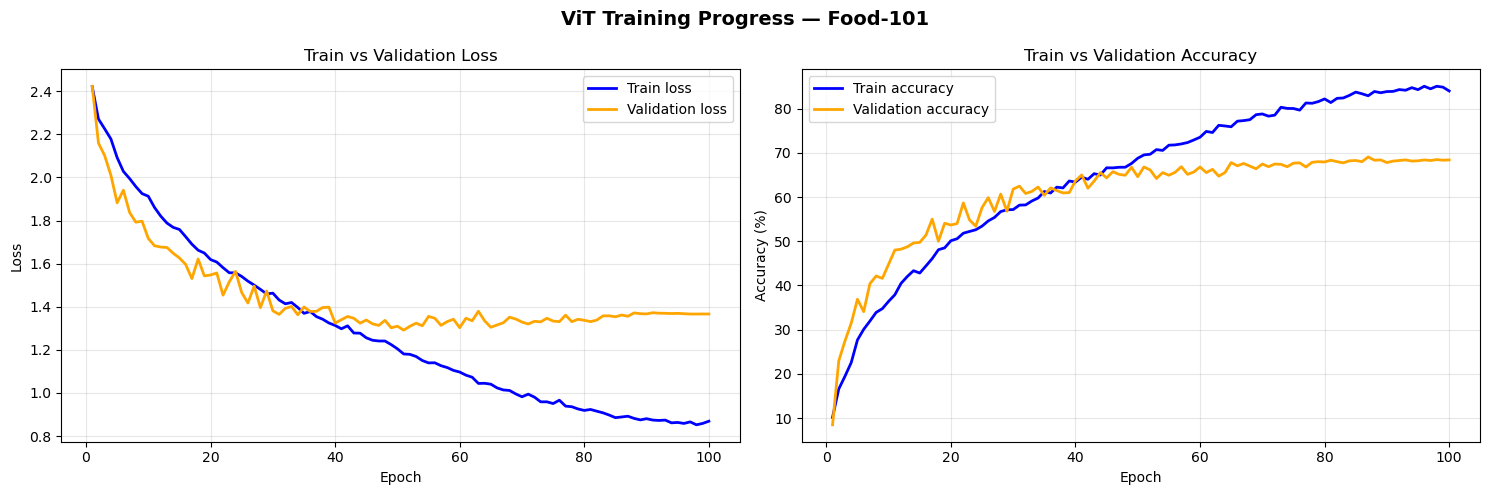

Final Train Acc: 84.00%  |  Best Validation Acc: 69.07%
Final Train Loss: 0.8689  |  Final Validation Loss: 1.3663


In [32]:
epochs = range(1, len(train_losses) + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# loss plot for both train and val
ax1.plot(epochs, train_losses, color='blue',   label='Train loss', linewidth=2)
ax1.plot(epochs, val_losses,  color='orange', label='Validation loss',  linewidth=2)
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Train vs Validation Loss')
ax1.legend()
ax1.grid(True, alpha=0.3)

# accuracy plot for both train and val
ax2.plot(epochs, train_accs, color='blue',   label='Train accuracy', linewidth=2)
ax2.plot(epochs, val_accs,  color='orange', label='Validation accuracy',  linewidth=2)
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.set_title('Train vs Validation Accuracy')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.suptitle('ViT Training Progress — Food-101', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('metrics.png')
plt.show()

print(f'Final Train Acc: {train_accs[-1]:.2f}%  |  Best Validation Acc: {best_acc:.2f}%')
print(f'Final Train Loss: {train_losses[-1]:.4f}  |  Final Validation Loss: {val_losses[-1]:.4f}')

In [ ]:
# load best checkpoint and predict on test set
model.load_state_dict(torch.load('best_vit.pth', map_location=DEVICE))
model.eval()

# predict on the test set and store the predicted class indices
all_preds = []
with torch.no_grad():
    for images in test_loader:
        images  = images.to(DEVICE)
        outputs = model(images)
        preds   = outputs.argmax(dim=1)
        all_preds.extend(preds.cpu().tolist())

# sanity check — number of predictions must match number of test images
assert len(all_preds) == len(test_df), \
    f'Mismatch: {len(all_preds)} predictions vs {len(test_df)} test images'

# convert predicted numbers back to class name strings
pred_labels = [idx2cls[p] for p in all_preds]

# build the submission file matching Kaggle's expected format
sample_sub = pd.read_csv(data_path / 'sample_submission.csv')
submission = pd.DataFrame({
    'original_index': test_df['original_index'],
    'label':          pred_labels
})
submission['label'] = pred_labels  # this line was missing

# Sanity check — must come AFTER assigning predictions
assert submission['label'].isna().sum() == 0, 'Missing predictions found'

# Save it
submission.to_csv('test3.csv', index=False)

print(f'Saved {len(submission)} predictions to test3.csv')
print(submission.head(10))
print(f'\nPrediction counts:')
print(submission['label'].value_counts())

Saved 2500 predictions to test3.csv
   original_index              label
0             250  hot_and_sour_soup
1             251  hot_and_sour_soup
2             252  hot_and_sour_soup
3             253  hot_and_sour_soup
4             254  hot_and_sour_soup
5             255  hot_and_sour_soup
6             256  hot_and_sour_soup
7             257  hot_and_sour_soup
8             258     baby_back_ribs
9             259  hot_and_sour_soup

Prediction counts:
label
hot_and_sour_soup    282
guacamole            277
dumplings            270
beef_tartare         263
french_onion_soup    262
pork_chop            253
baby_back_ribs       234
crab_cakes           228
cheesecake           221
sushi                210
Name: count, dtype: int64
